In [1]:
import sys
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import List, Dict, Tuple
from datetime import datetime

from assistax.baselines.sweep_plots import (
    load_npy_files,
    bootstrap_ci_mean,
    plot_auc_scatter,
    plot_auc_scatter_algorithm,
    plot_training_curves,
    analyze_performance,
    print_best_configs,
    create_groups
)

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


# IPPO FF Scratch

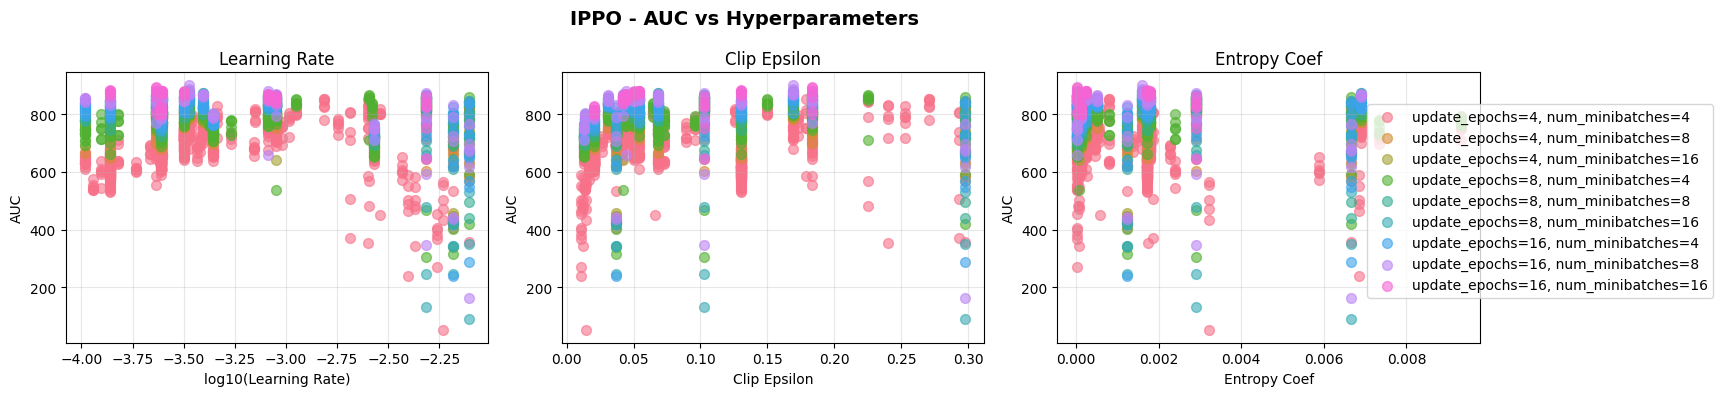

In [2]:
ippo_ff_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_si/metric/eval_returns.npy")
ippo_ff_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_si/hparam") 
# 3 side-by-side plots (lr, clip_eps, ent_coef) colored by update_epochs
#fig = plot_auc_scatter_algorithm(
#    ippo_ff_returns,
#    ippo_ff_hp_dict,
#    algorithm='ippo',
#    group_by='update_epochs'
#)

# Or grouped by combination of update_epochs AND num_minibatches
fig = plot_auc_scatter_algorithm(
    ippo_ff_returns,
    ippo_ff_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_ff_scratchitch.pdf", bbox_inches="tight")


In [3]:
# Print Best

performance_metrics, final_perfomance = analyze_performance(ippo_ff_returns, ippo_ff_hp_dict)

print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 288)
Final Performance: 937.19
AUC: 874.86
Max Performance: 942.36
Std Across Seeds: 6.56

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.16875672
  lr: 3.34e-04
  ent_coef: 0.0016069901

Rank 2 (Config 189)
Final Performance: 934.57
AUC: 877.30
Max Performance: 944.44
Std Across Seeds: 6.85

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.13002244
  lr: 1.37e-04
  ent_coef: 0.0017260804

Rank 3 (Config 195)
Final Performance: 931.54
AUC: 877.51
Max Performance: 939.87
Std Across Seeds: 3.90

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.05391901
  lr: 2.48e-04
  ent_coef: 0.00023118964

Rank 4 (Config 352)
Final Performance: 929.96
AUC: 881.05
Max Performance: 937.68
Std Across Seeds: 12.17

Hyperparameters:
  update_epochs: 16
  num_envs: 1024

# IPPO RNN Scratch 

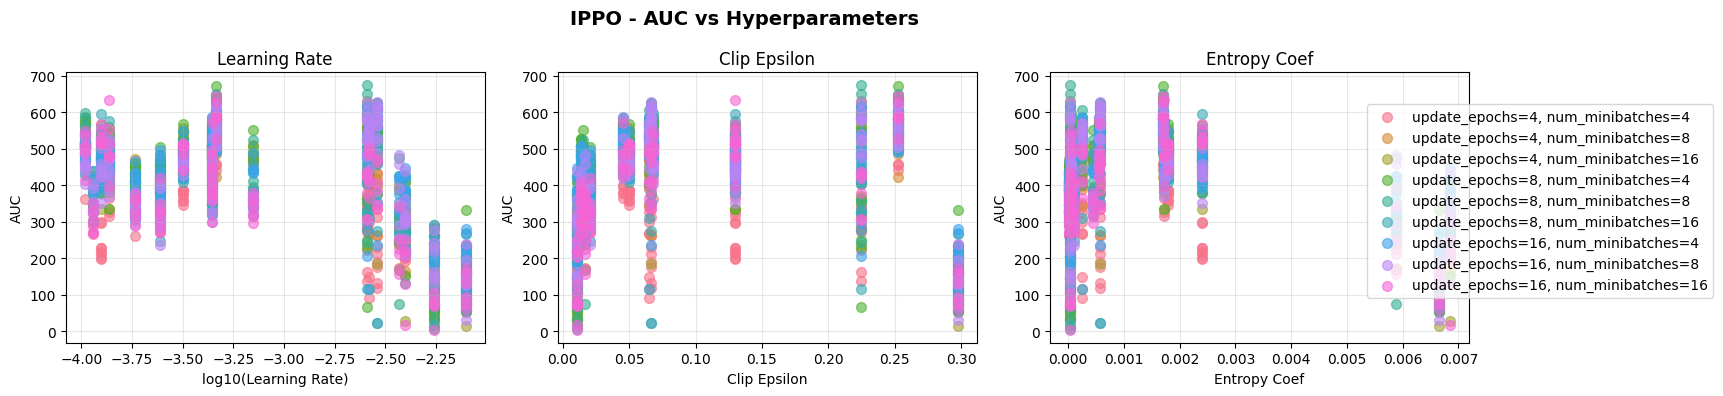

In [4]:
ippo_rnn_si_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_si_merge/metric/eval_returns.npy")
ippo_rnn_si_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_si_merge/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_si_returns,
    ippo_rnn_si_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_scratchitch.pdf", bbox_inches="tight")


In [5]:
performance_metrics, final_perfomance = analyze_performance(ippo_rnn_si_returns, ippo_rnn_si_hp_dict)

print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 185)
Final Performance: 736.26
AUC: 559.24
Max Performance: 766.14
Std Across Seeds: 17.66

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.045589864
  lr: 4.39e-04
  ent_coef: 0.000545135

Rank 2 (Config 184)
Final Performance: 730.63
AUC: 601.86
Max Performance: 788.02
Std Across Seeds: 29.74

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 4)
Final Performance: 727.22
AUC: 558.89
Max Performance: 775.54
Std Across Seeds: 65.55

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 4 (Config 67)
Final Performance: 725.70
AUC: 500.79
Max Performance: 771.28
Std Across Seeds: 39.11

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_

# IPPO FF Bed Bathing

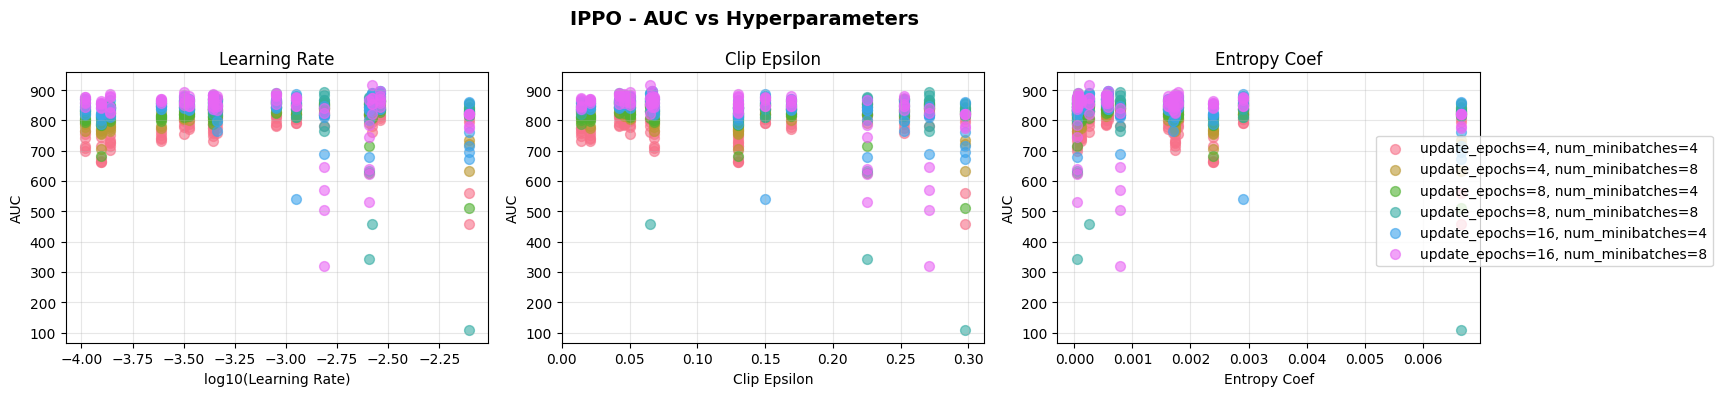

In [6]:
ippo_ff_bb_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_bb/metric/eval_returns.npy")
ippo_ff_bb_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_bb/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_ff_bb_returns,
    ippo_ff_bb_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_ff_bedbathing.pdf", bbox_inches="tight")


In [7]:
ippo_ff_bb_returns.shape

(96, 6, 610)

In [8]:
performance_metrics, final_perfomance = analyze_performance(ippo_ff_bb_returns, ippo_ff_bb_hp_dict)

print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 59)
Final Performance: 913.57
AUC: 857.10
Max Performance: 922.84
Std Across Seeds: 13.69

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.014019224
  lr: 4.43e-04
  ent_coef: 5.3705717e-05

Rank 2 (Config 84)
Final Performance: 910.48
AUC: 877.07
Max Performance: 932.63
Std Across Seeds: 13.19

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.041964713
  lr: 8.93e-04
  ent_coef: 6.376027e-05

Rank 3 (Config 30)
Final Performance: 908.98
AUC: 869.94
Max Performance: 919.18
Std Across Seeds: 11.84

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.045589864
  lr: 4.39e-04
  ent_coef: 0.000545135

Rank 4 (Config 34)
Final Performance: 907.65
AUC: 875.67
Max Performance: 926.87
Std Across Seeds: 11.08

Hyperparameters:
  update_epochs: 16
  num_envs: 1024


# IPPO RNN Bed Bathing

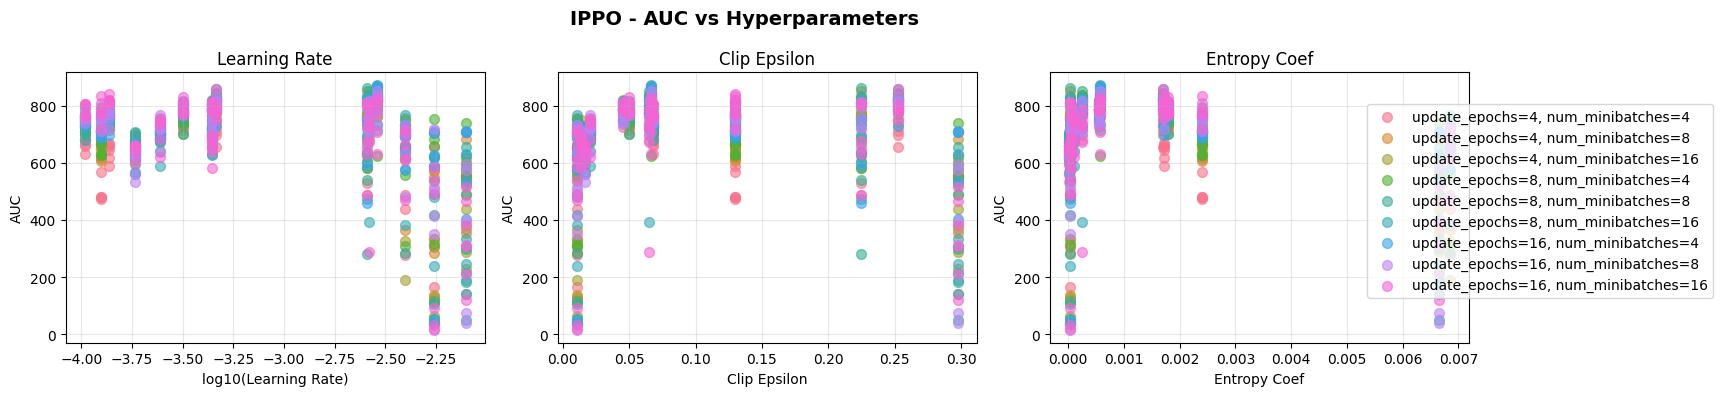

In [9]:
ippo_rnn_bb_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_bb/metric/eval_returns.npy")
ippo_rnn_bb_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_bb/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_bb_returns,
    ippo_rnn_bb_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_bedbathing.pdf", bbox_inches="tight")


In [10]:

performance_metrics, final_perfomance = analyze_performance(ippo_rnn_bb_returns, ippo_rnn_bb_hp_dict)

print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 84)
Final Performance: 901.27
AUC: 839.62
Max Performance: 918.71
Std Across Seeds: 28.04

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.06623137
  lr: 2.89e-03
  ent_coef: 0.0005725827

Rank 2 (Config 25)
Final Performance: 896.08
AUC: 805.34
Max Performance: 926.55
Std Across Seeds: 22.54

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 67)
Final Performance: 886.52
AUC: 807.82
Max Performance: 895.76
Std Across Seeds: 14.90

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.06491225
  lr: 2.64e-03
  ent_coef: 0.00024903467

Rank 4 (Config 4)
Final Performance: 882.19
AUC: 829.73
Max Performance: 906.56
Std Across Seeds: 14.50

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num

# IPPO FF Arm Assist

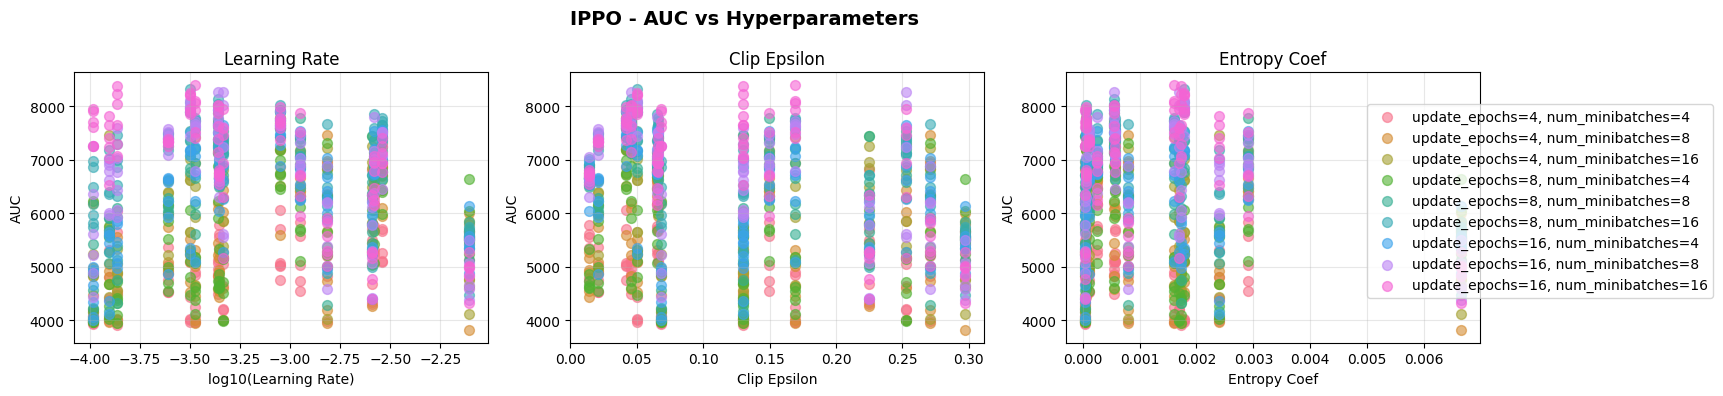

In [11]:
ippo_ff_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_aa/metric/eval_returns.npy")
ippo_ff_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_aa/hparam")

fig = plot_auc_scatter_algorithm(
    ippo_ff_aa_returns,
    ippo_ff_aa_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_ff_armmanipulation.pdf", bbox_inches="tight")


In [12]:
ippo_ff_aa_returns.shape

(144, 6, 610)

In [13]:
performance_metrics, final_perfomance = analyze_performance(ippo_ff_aa_returns, ippo_ff_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 38)
Final Performance: 8791.49
AUC: 7403.86
Max Performance: 8979.71
Std Across Seeds: 156.92

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.02069652
  lr: 2.45e-04
  ent_coef: 0.00010842521

Rank 2 (Config 36)
Final Performance: 8732.12
AUC: 7578.55
Max Performance: 8777.19
Std Across Seeds: 112.48

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.041964713
  lr: 8.93e-04
  ent_coef: 6.376027e-05

Rank 3 (Config 35)
Final Performance: 8693.18
AUC: 7127.43
Max Performance: 8848.48
Std Across Seeds: 267.35

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.05023645
  lr: 3.16e-04
  ent_coef: 0.0017809378

Rank 4 (Config 122)
Final Performance: 8678.33
AUC: 7334.12
Max Performance: 8758.41
Std Across Seeds: 39.30

Hyperparameters:
  update_epochs: 16
  nu

# IPPO RNN Arm Assist

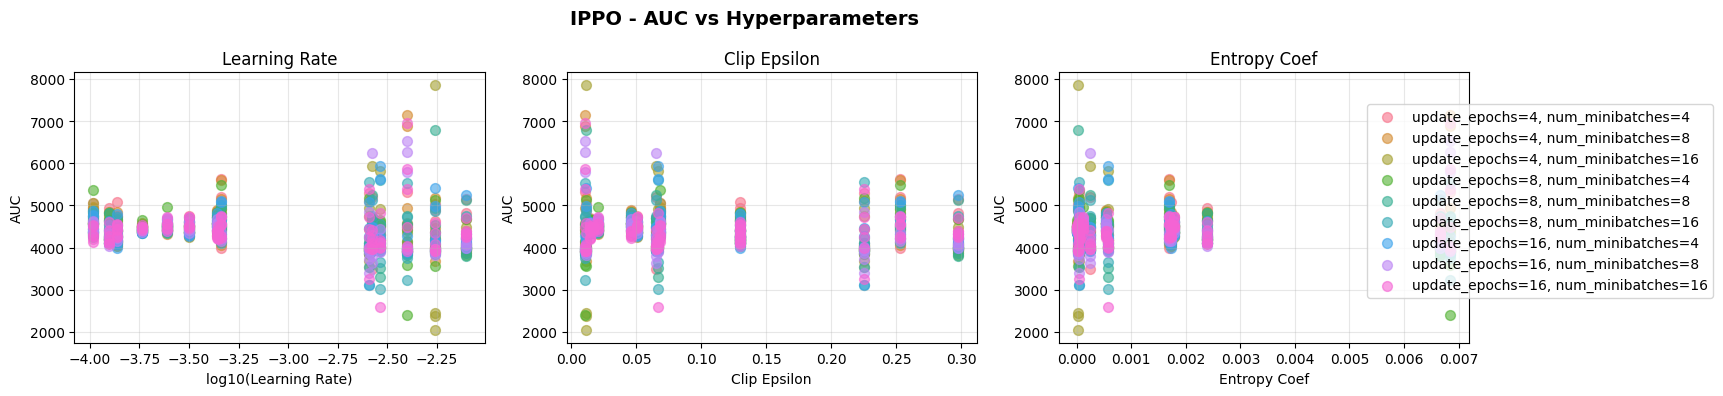

In [14]:
ippo_rnn_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_aa/metric/eval_returns.npy")
ippo_rnn_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_aa/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_aa_returns,
    ippo_rnn_aa_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_armmanipulation.pdf", bbox_inches="tight")


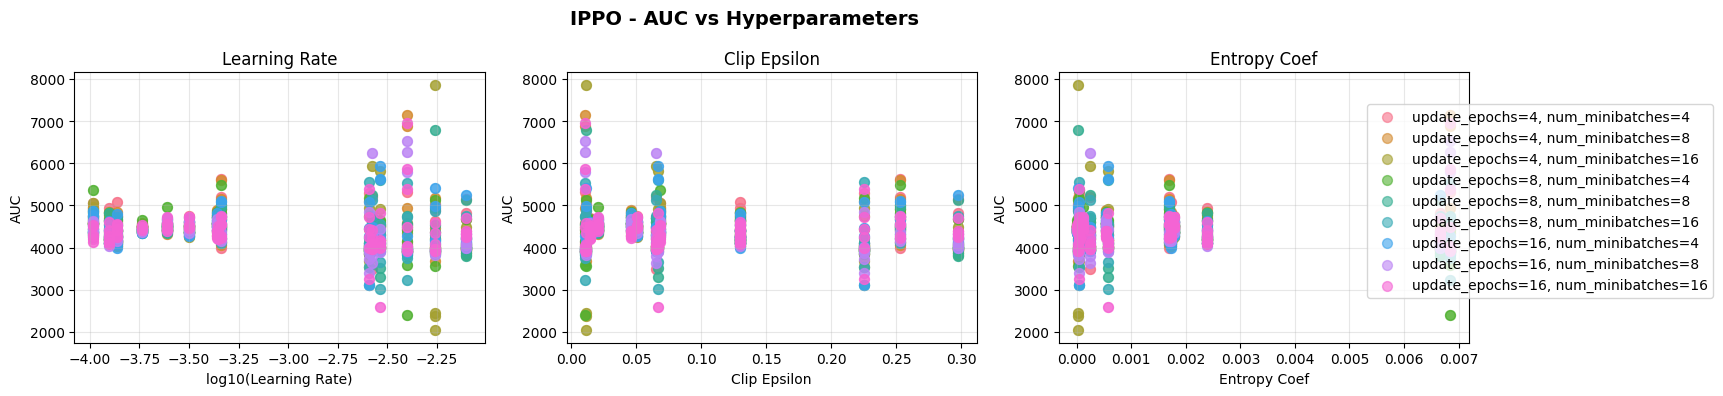

In [15]:
returns_path = "/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_aa_merge/metric/eval_returns.npy"
config_path = "/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_aa_merge/hparam"

ippo_rnn_aa_returns = np.load(returns_path)
ippo_rnn_aa_hp_dict = load_npy_files(config_path) 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_aa_returns,
    ippo_rnn_aa_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_armmanipulation.pdf", bbox_inches="tight")


In [16]:
performance_metrics, final_perfomance = analyze_performance(ippo_rnn_aa_returns, ippo_rnn_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 181)
Final Performance: 5830.41
AUC: 4763.64
Max Performance: 6105.24
Std Across Seeds: 371.38

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 2 (Config 46)
Final Performance: 5830.41
AUC: 4763.64
Max Performance: 6105.24
Std Across Seeds: 371.38

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 56)
Final Performance: 5438.02
AUC: 4487.11
Max Performance: 5620.31
Std Across Seeds: 404.52

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.011053424
  lr: 5.49e-03
  ent_coef: 2.4420386e-05

Rank 4 (Config 191)
Final Performance: 5438.02
AUC: 4487.11
Max Performance: 5620.31
Std Across Seeds: 404.52

Hyperparameters:
  update_epochs: 4
  nu

# IPPO FF Feeding

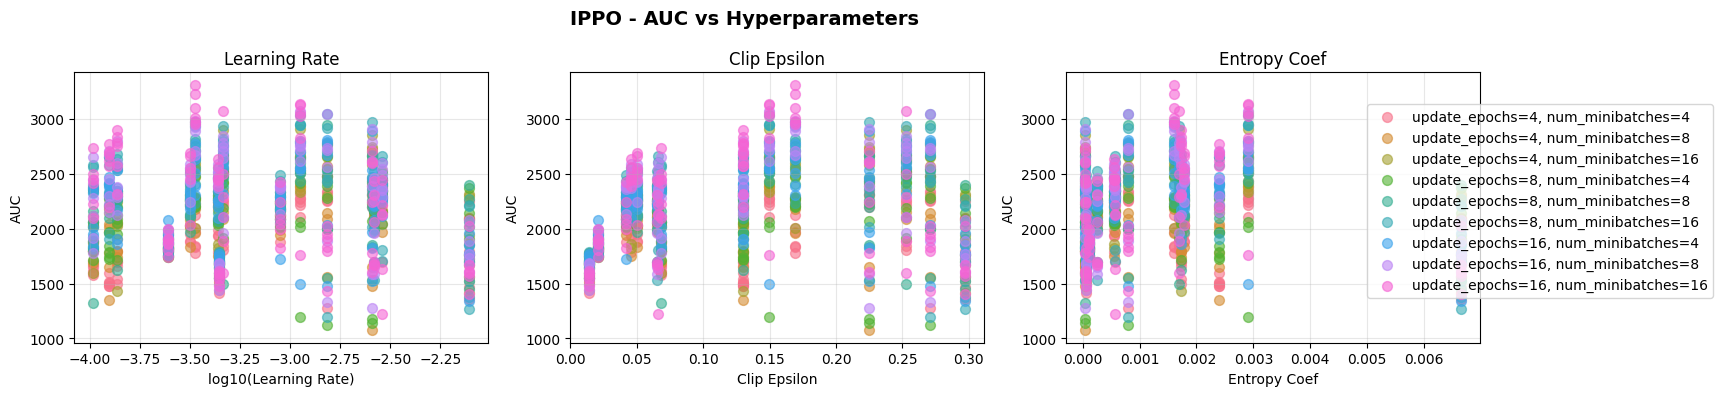

In [17]:
# TODO
ippo_ff_feed_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_feed/metric/eval_returns.npy")
ippo_ff_feed_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_feed/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_ff_feed_returns,
    ippo_ff_feed_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_ff_feeding.pdf", bbox_inches="tight")


In [18]:
performance_metrics, final_perfomance = analyze_performance(ippo_ff_feed_returns, ippo_ff_feed_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 68)
Final Performance: 3534.82
AUC: 3092.47
Max Performance: 3576.45
Std Across Seeds: 133.50

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.16875672
  lr: 3.34e-04
  ent_coef: 0.0016069901

Rank 2 (Config 128)
Final Performance: 3423.44
AUC: 2886.68
Max Performance: 3460.78
Std Across Seeds: 128.77

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.14979327
  lr: 1.12e-03
  ent_coef: 0.0029010084

Rank 3 (Config 88)
Final Performance: 3285.35
AUC: 2852.62
Max Performance: 3355.70
Std Across Seeds: 121.58

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.16875672
  lr: 3.34e-04
  ent_coef: 0.0016069901

Rank 4 (Config 137)
Final Performance: 3268.65
AUC: 2670.33
Max Performance: 3359.69
Std Across Seeds: 109.60

Hyperparameters:
  update_epochs: 4
  

# IPPO RNN Feeding

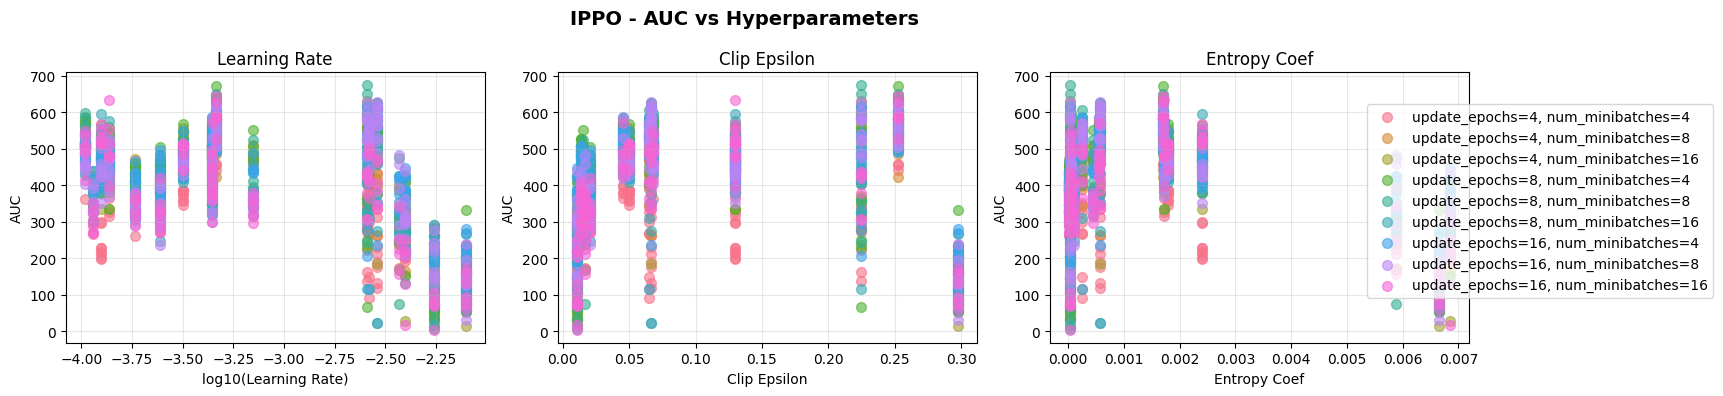

In [19]:
ippo_rnn_feed_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_si_merge/metric/eval_returns.npy")
ippo_rnn_feed_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_si_merge/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_feed_returns,
    ippo_rnn_feed_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_feeding.pdf", bbox_inches="tight")


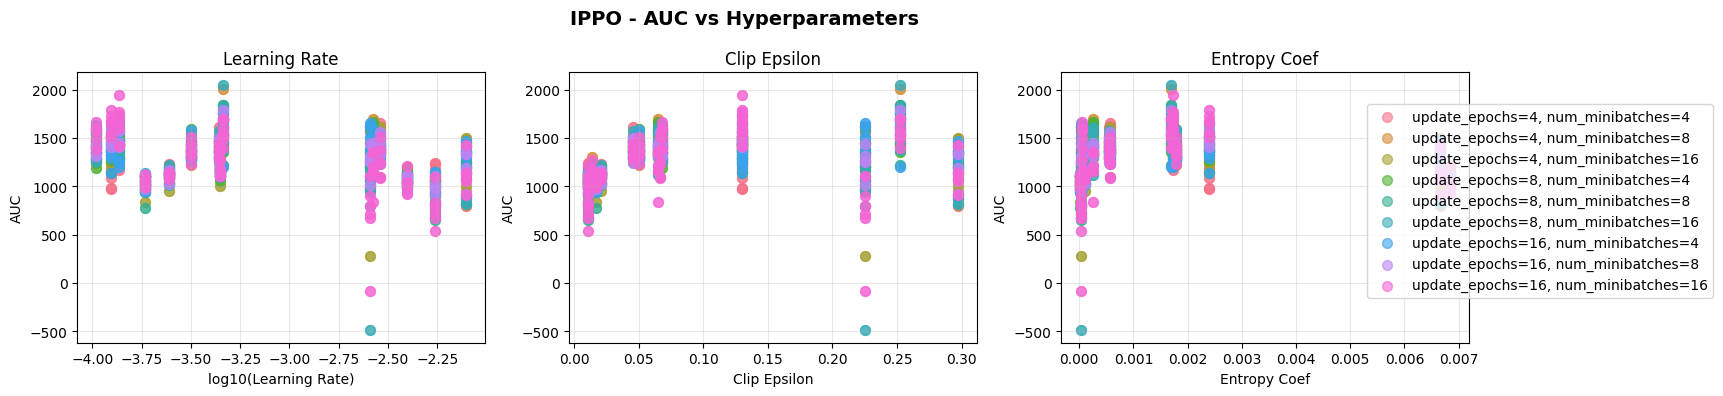

In [20]:
ippo_rnn_feed_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_feed_merge/metric/eval_returns.npy")
ippo_rnn_feed_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_feed_merge/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_feed_returns,
    ippo_rnn_feed_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_feeding.pdf", bbox_inches="tight")


In [21]:
ippo_rnn_feed_returns.shape

(270, 6, 610)

In [22]:
performance_metrics, final_perfomance = analyze_performance(ippo_rnn_feed_returns, ippo_rnn_feed_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 82)
Final Performance: 1927.23
AUC: 1624.76
Max Performance: 2034.71
Std Across Seeds: 214.34

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 2 (Config 217)
Final Performance: 1927.23
AUC: 1624.76
Max Performance: 2034.71
Std Across Seeds: 214.34

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 259)
Final Performance: 1911.89
AUC: 1690.86
Max Performance: 2088.08
Std Across Seeds: 161.23

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.13002244
  lr: 1.37e-04
  ent_coef: 0.0017260804

Rank 4 (Config 124)
Final Performance: 1911.89
AUC: 1690.86
Max Performance: 2088.08
Std Across Seeds: 161.23

Hyperparameters:
  update_epochs: 16
  

# IPPO FF Teeth

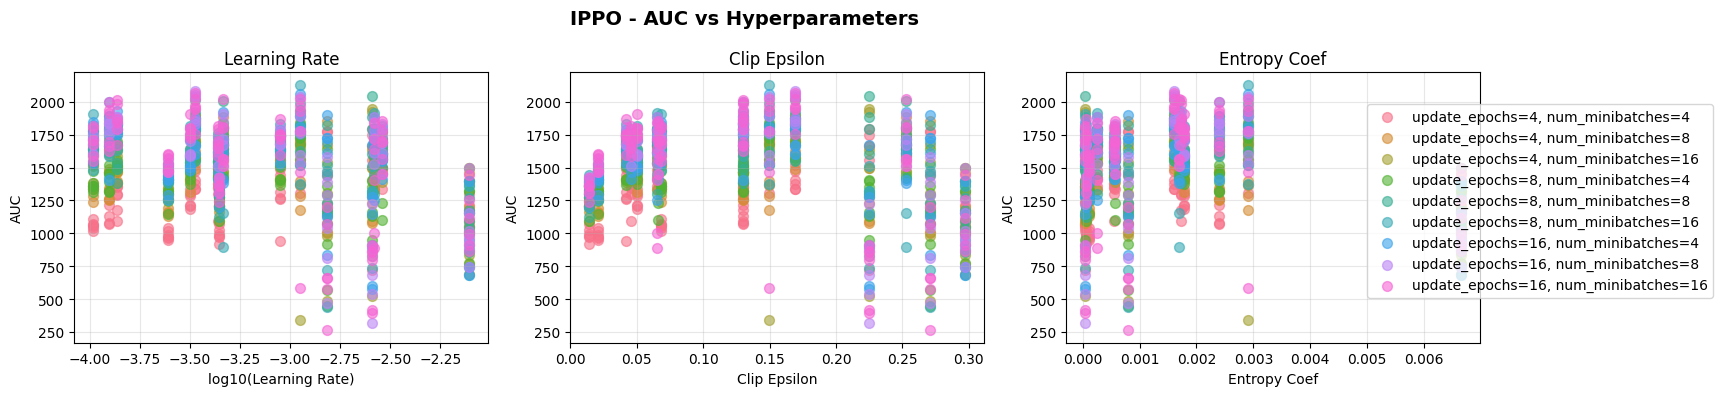

In [23]:
ippo_ff_teeth_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_teeth/metric/eval_returns.npy")
ippo_ff_teeth_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_teeth/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_ff_teeth_returns,
    ippo_ff_teeth_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_ff_teethbrushing.pdf", bbox_inches="tight")


In [24]:
performance_metrics, final_perfomance = analyze_performance(ippo_ff_teeth_returns, ippo_ff_teeth_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 132)
Final Performance: 2220.46
AUC: 1803.42
Max Performance: 2240.72
Std Across Seeds: 78.20

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.16875672
  lr: 3.34e-04
  ent_coef: 0.0016069901

Rank 2 (Config 58)
Final Performance: 2217.98
AUC: 1666.28
Max Performance: 2233.13
Std Across Seeds: 75.47

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.068054095
  lr: 1.04e-04
  ent_coef: 4.2520485e-05

Rank 3 (Config 15)
Final Performance: 2208.98
AUC: 1704.58
Max Performance: 2222.32
Std Across Seeds: 161.96

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.12996225
  lr: 1.25e-04
  ent_coef: 0.0023909595

Rank 4 (Config 1)
Final Performance: 2172.09
AUC: 1809.49
Max Performance: 2188.13
Std Across Seeds: 58.56

Hyperparameters:
  update_epochs: 16
  num_e

# IPPO RNN Teeth

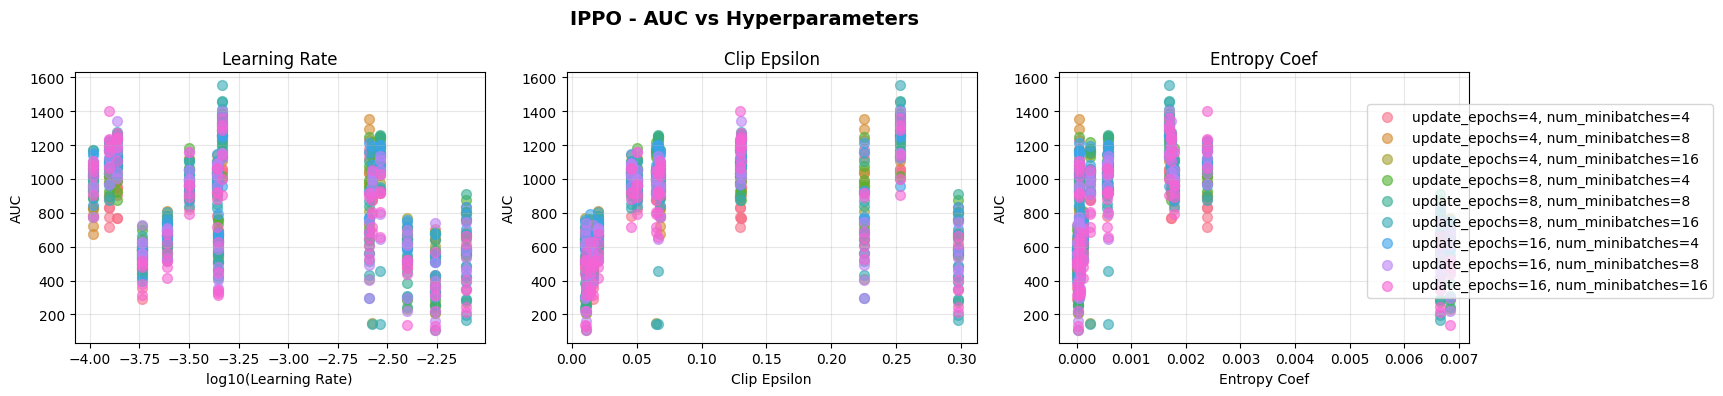

In [25]:
ippo_rnn_teeth_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_teeth/metric/eval_returns.npy")
ippo_rnn_teeth_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_teeth/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_teeth_returns,
    ippo_rnn_teeth_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_ippo_rnn_teethbrushing.pdf", bbox_inches="tight")


In [26]:
performance_metrics, final_perfomance = analyze_performance(ippo_rnn_teeth_returns, ippo_rnn_teeth_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 123)
Final Performance: 1668.35
AUC: 1214.26
Max Performance: 1767.23
Std Across Seeds: 100.05

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.12996225
  lr: 1.25e-04
  ent_coef: 0.0023909595

Rank 2 (Config 118)
Final Performance: 1552.51
AUC: 1214.57
Max Performance: 1721.38
Std Across Seeds: 54.63

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.13002244
  lr: 1.37e-04
  ent_coef: 0.0017260804

Rank 3 (Config 110)
Final Performance: 1507.64
AUC: 1044.25
Max Performance: 1551.71
Std Across Seeds: 48.64

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.045589864
  lr: 4.39e-04
  ent_coef: 0.000545135

Rank 4 (Config 31)
Final Performance: 1504.42
AUC: 1261.95
Max Performance: 1653.53
Std Across Seeds: 99.41

Hyperparameters:
  update_epochs: 8
  n

# MAPPO FF SI

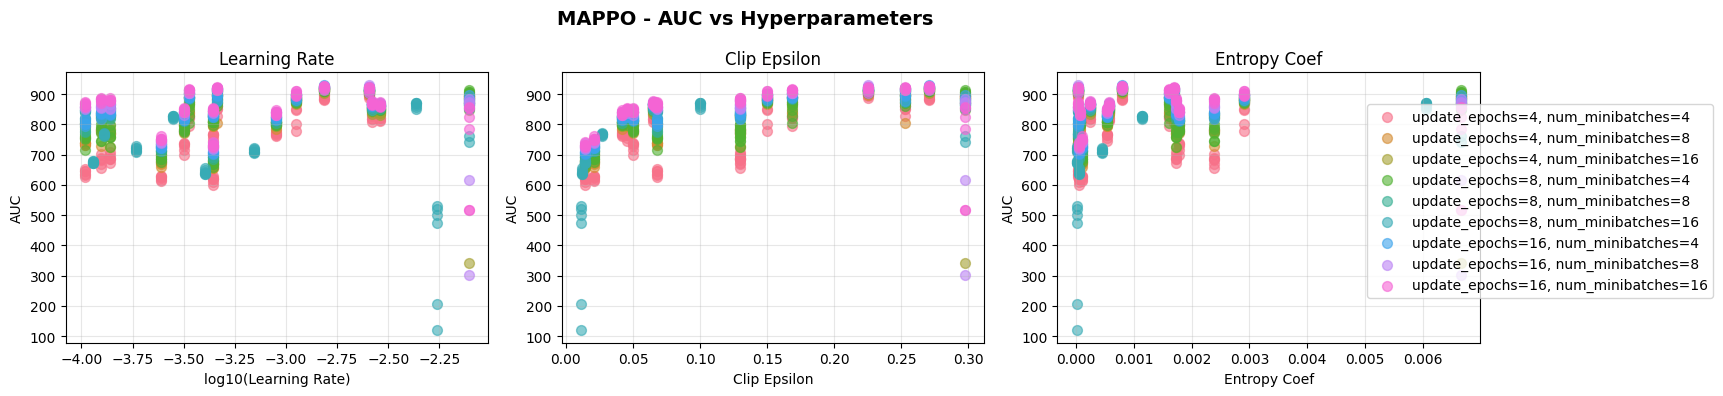

In [27]:
mappo_ff_si_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_si/metric/eval_returns.npy")
mappo_ff_si_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_si/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_ff_si_returns,
    mappo_ff_si_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_ff_scratchitch.pdf", bbox_inches="tight")


In [28]:
performance_metrics, final_perfomance = analyze_performance(mappo_ff_si_returns, mappo_ff_si_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 62)
Final Performance: 960.43
AUC: 911.08
Max Performance: 961.84
Std Across Seeds: 3.36

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 4
  num_steps: 128
  clip_eps: 0.22490497
  lr: 2.56e-03
  ent_coef: 3.914155e-05

Rank 2 (Config 48)
Final Performance: 959.02
AUC: 914.14
Max Performance: 963.22
Std Across Seeds: 5.17

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.2705661
  lr: 1.54e-03
  ent_coef: 0.000794748

Rank 3 (Config 66)
Final Performance: 956.99
AUC: 907.47
Max Performance: 961.37
Std Across Seeds: 4.87

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.22490497
  lr: 2.56e-03
  ent_coef: 3.914155e-05

Rank 4 (Config 125)
Final Performance: 955.76
AUC: 897.93
Max Performance: 958.17
Std Across Seeds: 7.29

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_min

# MAPPO RNN SI

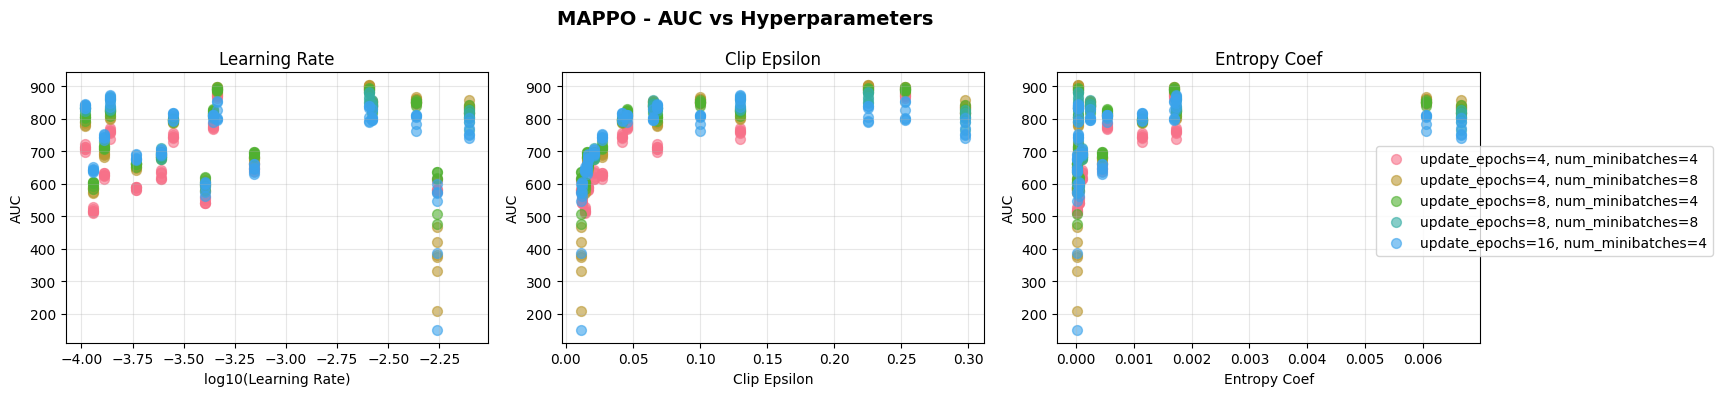

In [29]:
mappo_rnn_si_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_si/metric/eval_returns.npy")
mappo_rnn_si_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_si/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_rnn_si_returns,
    mappo_rnn_si_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_rnn_scratchitch.pdf", bbox_inches="tight")


In [30]:
performance_metrics, final_perfomance = analyze_performance(mappo_rnn_si_returns, mappo_rnn_si_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 15)
Final Performance: 954.14
AUC: 891.35
Max Performance: 957.50
Std Across Seeds: 5.22

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 2 (Config 31)
Final Performance: 951.57
AUC: 870.68
Max Performance: 956.79
Std Across Seeds: 4.72

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 4
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 27)
Final Performance: 946.09
AUC: 889.27
Max Performance: 949.45
Std Across Seeds: 3.58

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 4
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 4 (Config 64)
Final Performance: 944.54
AUC: 895.23
Max Performance: 947.40
Std Across Seeds: 4.62

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_mi

# MAPPO FF BB (To-Do)

In [32]:
mappo_ff_bb_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_bb/metric/eval_returns.npy")
mappo_ff_bb_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_bb/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_ff_bb_returns,
    mappo_ff_bb_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_ff_bedbathing.pdf", bbox_inches="tight")


FileNotFoundError: [Errno 2] No such file or directory: '/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_bb/metric/eval_returns.npy'

# MAPPO RNN BB

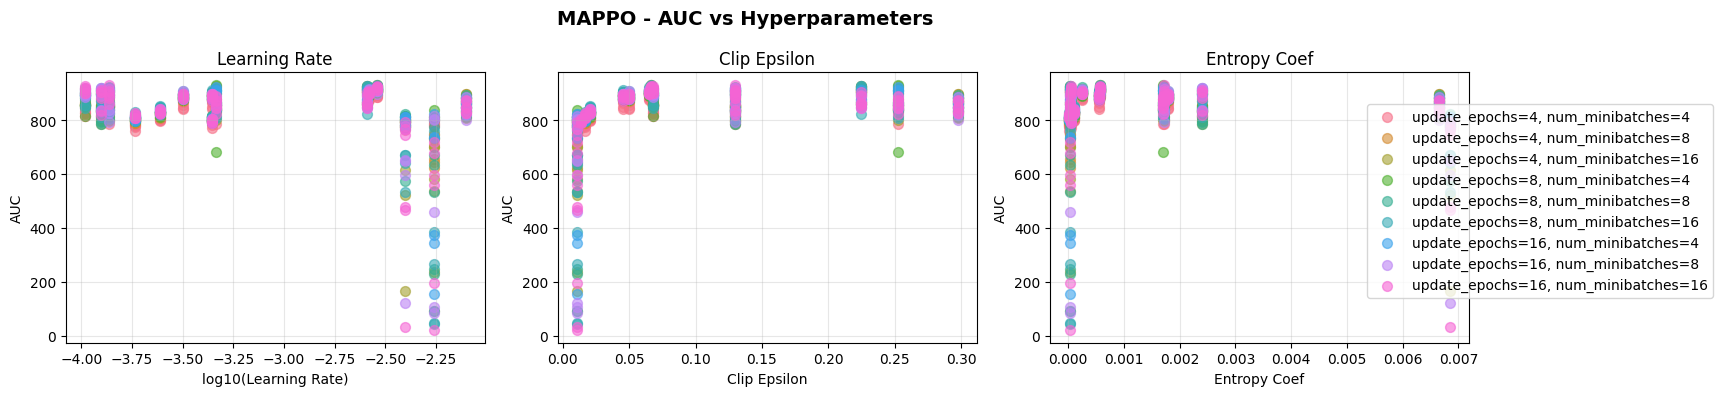

In [33]:
mappo_rnn_bb_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_bb/metric/eval_returns.npy")
mappo_rnn_bb_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_bb/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_rnn_bb_returns,
    mappo_rnn_bb_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_rnn_bedbathing.pdf", bbox_inches="tight")


In [34]:
performance_metrics, final_perfomance = analyze_performance(mappo_rnn_bb_returns, mappo_rnn_bb_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 116)
Final Performance: 964.37
AUC: 913.10
Max Performance: 970.31
Std Across Seeds: 9.28

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.068054095
  lr: 1.04e-04
  ent_coef: 4.2520485e-05

Rank 2 (Config 80)
Final Performance: 964.28
AUC: 904.21
Max Performance: 968.54
Std Across Seeds: 3.62

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.045589864
  lr: 4.39e-04
  ent_coef: 0.000545135

Rank 3 (Config 81)
Final Performance: 960.55
AUC: 926.19
Max Performance: 965.85
Std Across Seeds: 3.11

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.06623137
  lr: 2.89e-03
  ent_coef: 0.0005725827

Rank 4 (Config 129)
Final Performance: 959.62
AUC: 918.42
Max Performance: 967.60
Std Across Seeds: 5.94

Hyperparameters:
  update_epochs: 16
  num_envs: 1024

# MAPPO FF AA (To-do)

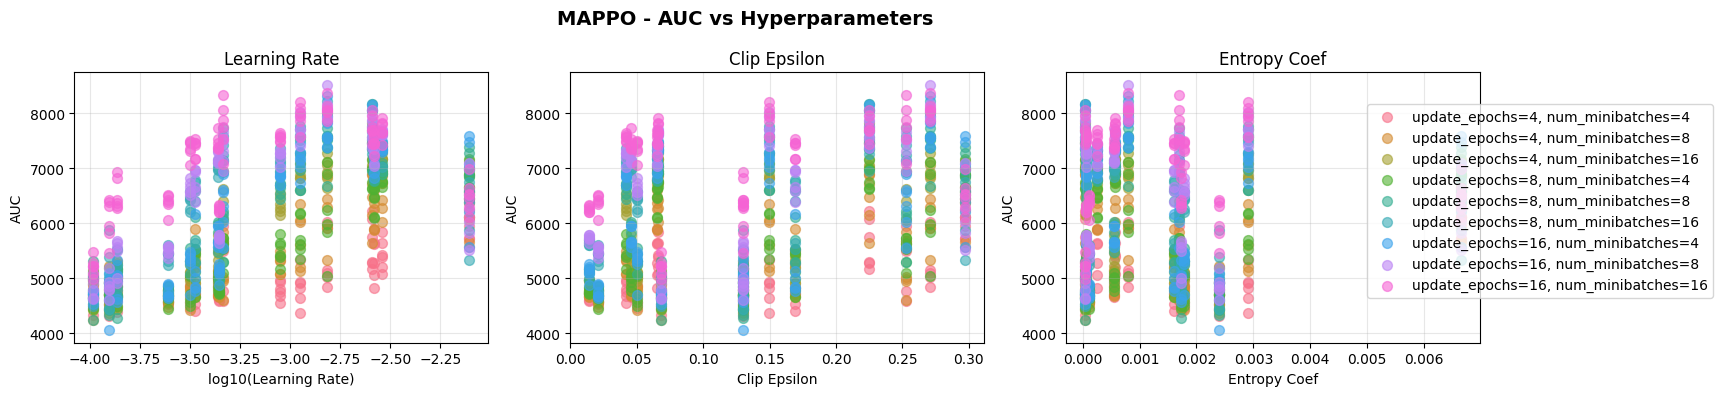

In [35]:
mappo_ff_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_aa/metric/eval_returns.npy")
mappo_ff_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_aa/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_ff_aa_returns,
    mappo_ff_aa_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_ff_armmanipulation.pdf", bbox_inches="tight")


In [36]:
performance_metrics, final_perfomance = analyze_performance(mappo_ff_aa_returns, mappo_ff_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 40)
Final Performance: 8995.70
AUC: 7750.96
Max Performance: 9090.02
Std Across Seeds: 298.81

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 4
  num_steps: 128
  clip_eps: 0.2705661
  lr: 1.54e-03
  ent_coef: 0.000794748

Rank 2 (Config 108)
Final Performance: 8969.20
AUC: 8116.64
Max Performance: 9182.39
Std Across Seeds: 203.88

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.2705661
  lr: 1.54e-03
  ent_coef: 0.000794748

Rank 3 (Config 128)
Final Performance: 8951.15
AUC: 7373.52
Max Performance: 9142.79
Std Across Seeds: 147.96

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.16875672
  lr: 3.34e-04
  ent_coef: 0.0016069901

Rank 4 (Config 105)
Final Performance: 8909.48
AUC: 7348.04
Max Performance: 9032.70
Std Across Seeds: 247.39

Hyperparameters:
  update_epochs: 16
 

# MAPPO RNN AA

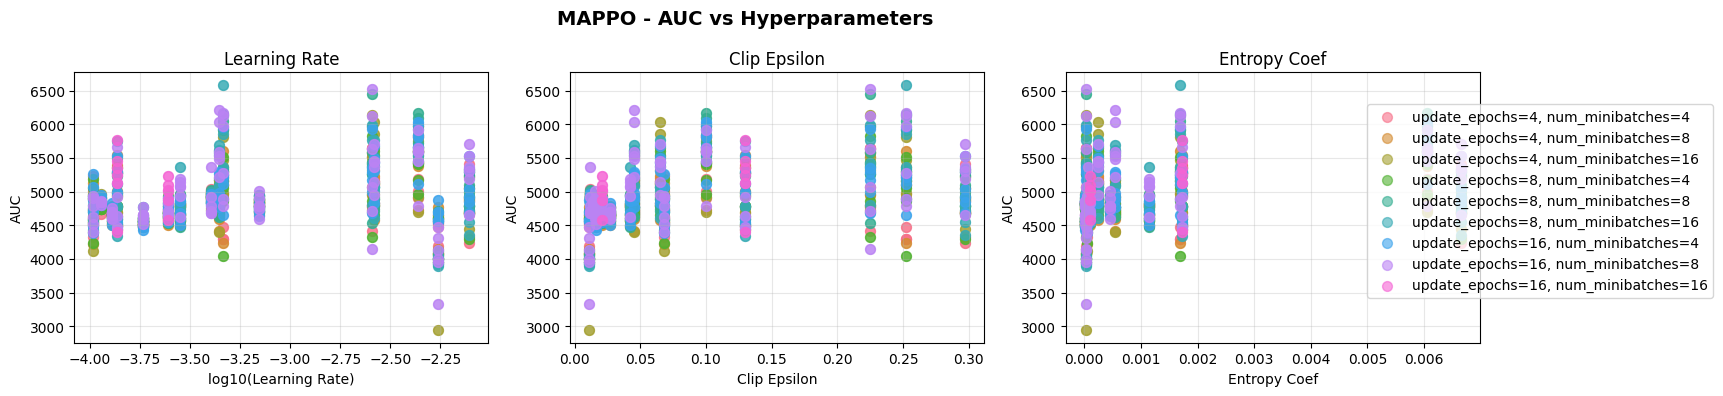

In [37]:
mappo_rnn_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_aa_2_merge/metric/eval_returns.npy")
mappo_rnn_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_aa_2_merge/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_rnn_aa_returns,
    mappo_rnn_aa_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_rnn_armmanipulation.pdf", bbox_inches="tight")


In [38]:
performance_metrics, final_perfomance = analyze_performance(mappo_rnn_aa_returns, mappo_rnn_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 213)
Final Performance: 7490.46
AUC: 5844.83
Max Performance: 7767.88
Std Across Seeds: 469.16

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 2 (Config 83)
Final Performance: 7490.46
AUC: 5844.83
Max Performance: 7767.88
Std Across Seeds: 469.16

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 58)
Final Performance: 7166.18
AUC: 5672.45
Max Performance: 7287.07
Std Across Seeds: 343.42

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.045589864
  lr: 4.39e-04
  ent_coef: 0.000545135

Rank 4 (Config 188)
Final Performance: 7166.18
AUC: 5672.45
Max Performance: 7287.07
Std Across Seeds: 343.42

Hyperparameters:
  update_epochs: 16

# MAPPO FF Feeding

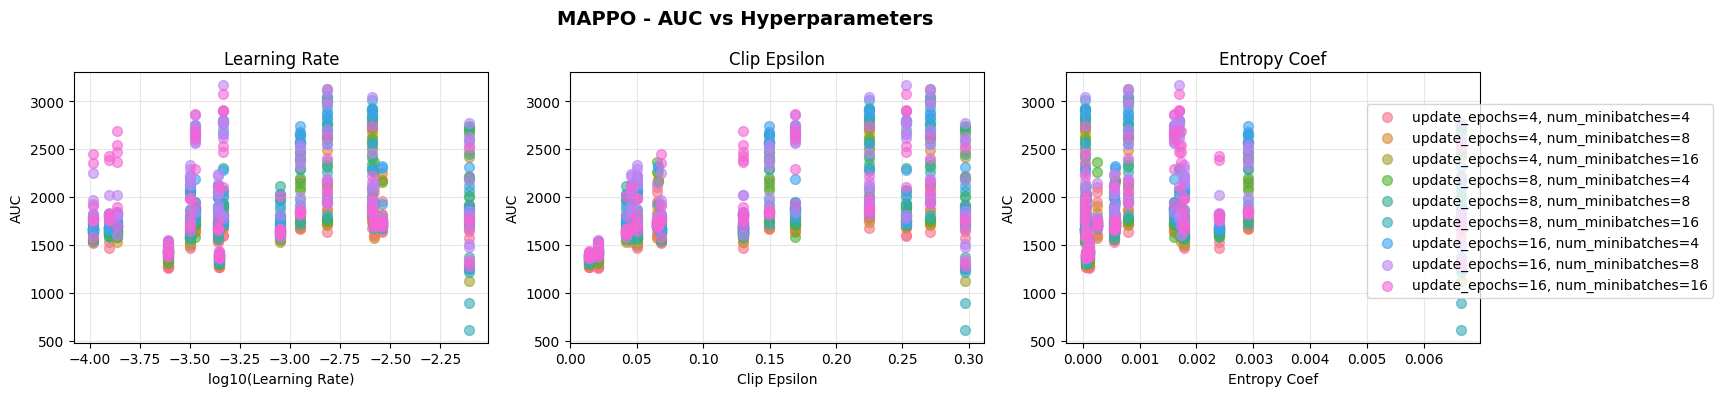

In [39]:
mappo_ff_feed_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_feed/metric/eval_returns.npy")
mappo_ff_feed_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_feed/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_ff_feed_returns,
    mappo_ff_feed_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_ff_feeding.pdf", bbox_inches="tight")


In [40]:
performance_metrics, final_perfomance = analyze_performance(mappo_ff_feed_returns, mappo_ff_feed_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 152)
Final Performance: 3376.15
AUC: 2806.07
Max Performance: 3534.39
Std Across Seeds: 345.62

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.2705661
  lr: 1.54e-03
  ent_coef: 0.000794748

Rank 2 (Config 169)
Final Performance: 3344.88
AUC: 2663.57
Max Performance: 3387.78
Std Across Seeds: 330.15

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 3 (Config 38)
Final Performance: 3239.26
AUC: 2747.50
Max Performance: 3339.11
Std Across Seeds: 256.71

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 4
  num_steps: 128
  clip_eps: 0.22490497
  lr: 2.56e-03
  ent_coef: 3.914155e-05

Rank 4 (Config 84)
Final Performance: 3233.17
AUC: 2670.41
Max Performance: 3261.41
Std Across Seeds: 67.27

Hyperparameters:
  update_epochs: 16
 

# MAPPO RNN Feeding

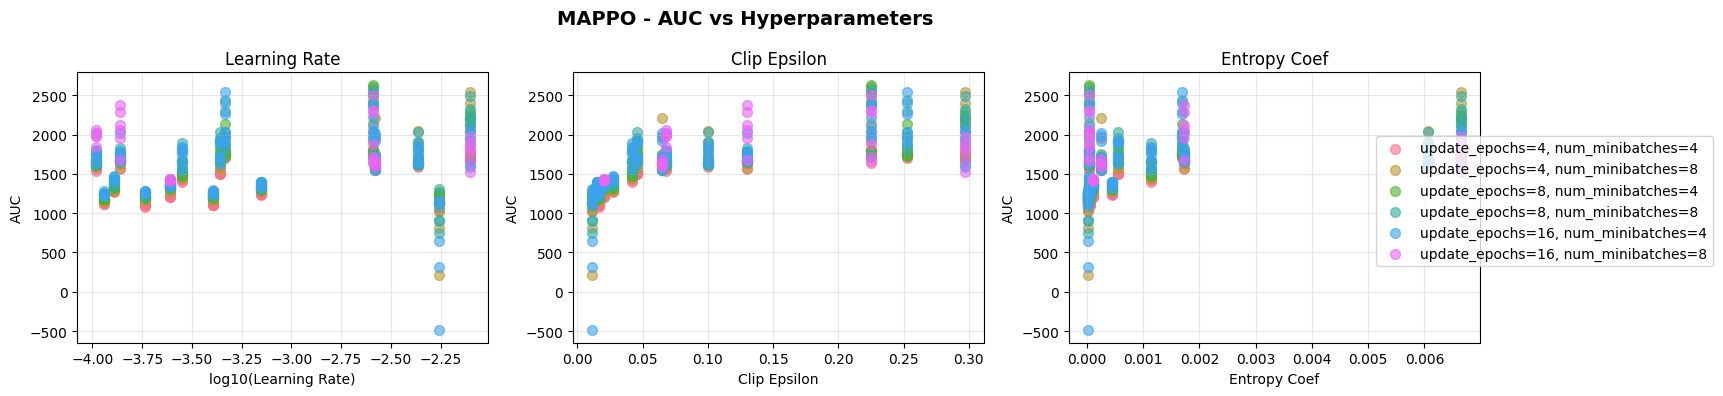

In [41]:
mappo_rnn_feed_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_feed/metric/eval_returns.npy")
mappo_rnn_feed_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_rnn_feed/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_rnn_feed_returns,
    mappo_rnn_feed_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_rnn_feeding.pdf", bbox_inches="tight")


In [42]:
performance_metrics, final_perfomance = analyze_performance(mappo_rnn_feed_returns, mappo_rnn_feed_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 12)
Final Performance: 2859.36
AUC: 2340.97
Max Performance: 2915.16
Std Across Seeds: 278.20

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.22490497
  lr: 2.56e-03
  ent_coef: 3.914155e-05

Rank 2 (Config 72)
Final Performance: 2744.92
AUC: 1870.60
Max Performance: 2778.54
Std Across Seeds: 122.68

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.045589864
  lr: 4.39e-04
  ent_coef: 0.000545135

Rank 3 (Config 49)
Final Performance: 2686.13
AUC: 2178.32
Max Performance: 2752.56
Std Across Seeds: 237.91

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 4
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 4 (Config 34)
Final Performance: 2638.15
AUC: 2117.62
Max Performance: 2691.55
Std Across Seeds: 144.89

Hyperparameters:
  update_epochs: 16
  n

# MAPPO FF Teeth

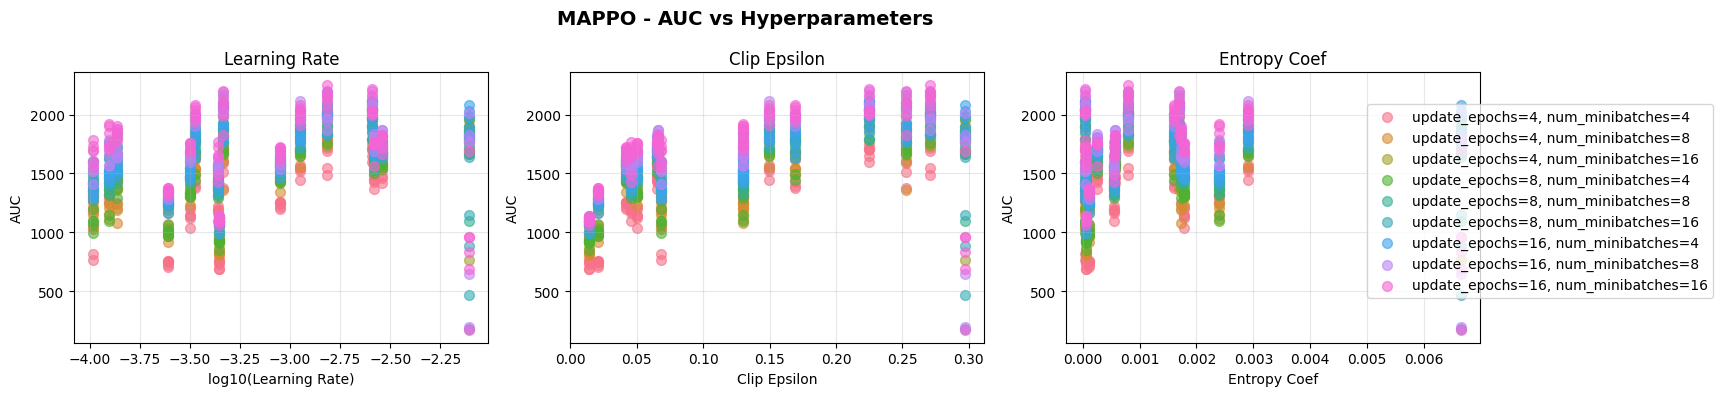

In [43]:
mappo_ff_teeth_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_teeth/metric/eval_returns.npy")
mappo_ff_teeth_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/mappo_ff_teeth/hparam") 

fig = plot_auc_scatter_algorithm(
    mappo_ff_teeth_returns,
    mappo_ff_teeth_hp_dict,
    algorithm='mappo',
    group_by=['update_epochs', 'num_minibatches']
)
fig.savefig("assistax/baselines/figs/sweep_mappo_ff_teethbrushing.pdf", bbox_inches="tight")


In [44]:
performance_metrics, final_perfomance = analyze_performance(mappo_ff_teeth_returns, mappo_ff_teeth_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 141)
Final Performance: 2399.05
AUC: 2018.19
Max Performance: 2430.29
Std Across Seeds: 125.53

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 2 (Config 140)
Final Performance: 2389.98
AUC: 2152.68
Max Performance: 2434.23
Std Across Seeds: 66.04

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 128
  clip_eps: 0.2705661
  lr: 1.54e-03
  ent_coef: 0.000794748

Rank 3 (Config 85)
Final Performance: 2387.94
AUC: 2078.63
Max Performance: 2431.08
Std Across Seeds: 60.39

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 128
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 4 (Config 136)
Final Performance: 2383.26
AUC: 2017.02
Max Performance: 2410.53
Std Across Seeds: 48.55

Hyperparameters:
  update_epochs: 16
  

# MAPPO RNN Teeth (TODO)


# MASAC FF SI

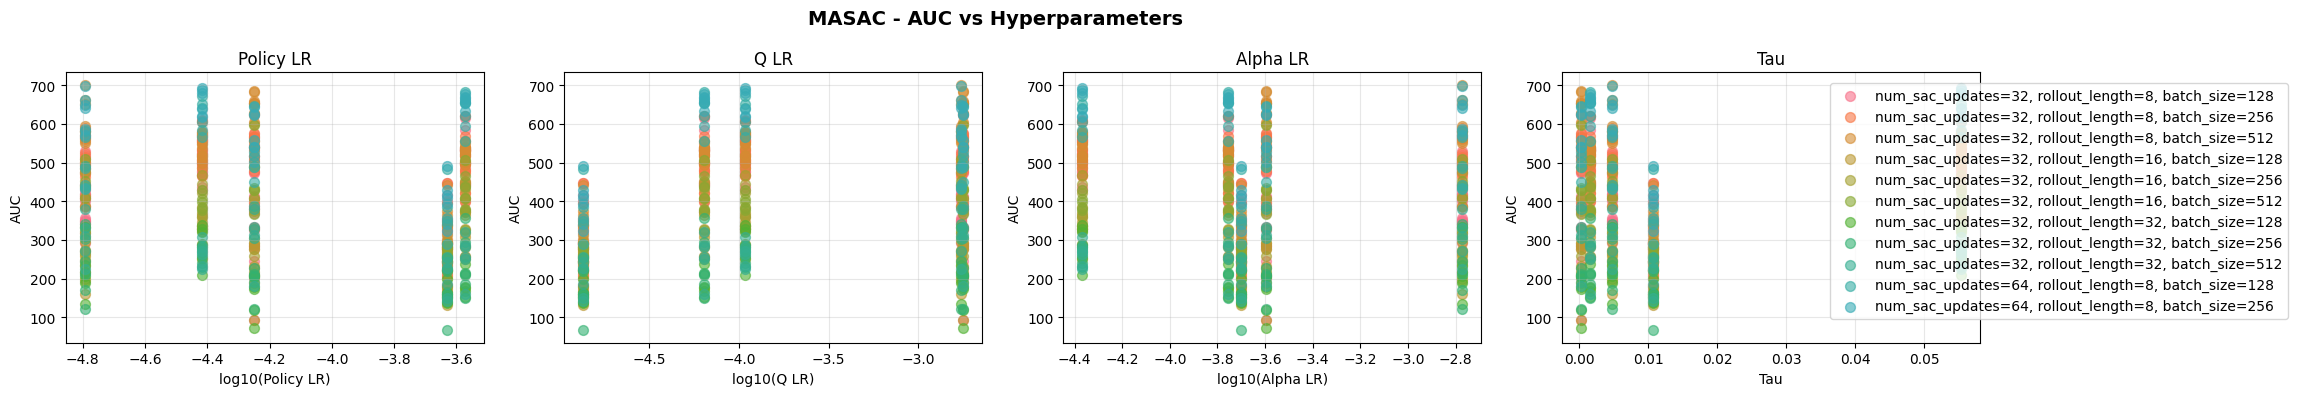

In [45]:
masac_ff_si_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_si/metric/eval_returns.npy")
masac_ff_si_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_si/hparam") 

fig = plot_auc_scatter_algorithm(
    masac_ff_si_returns,
    masac_ff_si_hp_dict,
    algorithm='masac',
    group_by=['num_sac_updates', 'rollout_length', "batch_size"]
)
fig.savefig("assistax/baselines/figs/sweep_masac_ff_scratchitch.pdf", bbox_inches="tight")


In [46]:
performance_metrics, final_perfomance = analyze_performance(masac_ff_si_returns, masac_ff_si_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 3)
Final Performance: 786.25
AUC: 631.19
Max Performance: 833.75
Std Across Seeds: 47.60

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 5.62e-05
  tau: 0.0002728487
  batch_size: 512

Rank 2 (Config 72)
Final Performance: 775.58
AUC: 655.94
Max Performance: 833.02
Std Across Seeds: 31.29

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.08e-04
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 4.28e-05
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 3.84e-05
  tau: 0.055368472
  batch_size: 256

Rank 3 (Config 58)
Final Performance: 772.22
AUC: 613.45
Max Performance: 816.21
Std Across Seeds: 48.28

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  bu

# MASAC FF BB

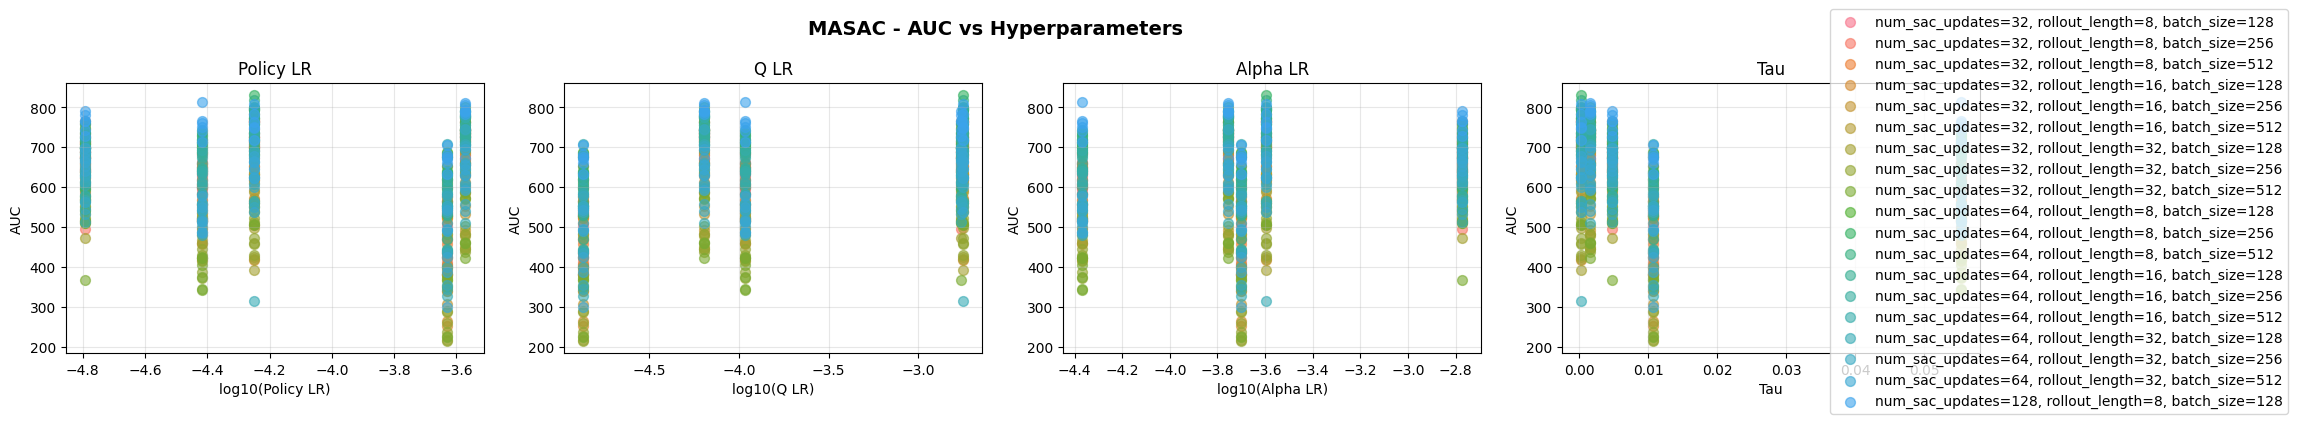

In [47]:
masac_ff_bb_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_bb/metric/eval_returns.npy")
masac_ff_bb_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_bb/hparam") 

fig = plot_auc_scatter_algorithm(
    masac_ff_bb_returns,
    masac_ff_bb_hp_dict,
    algorithm='masac',
    group_by=['num_sac_updates', 'rollout_length', "batch_size"]
)
fig.savefig("assistax/baselines/figs/sweep_masac_ff_bedbathing.pdf", bbox_inches="tight")


In [48]:
performance_metrics, final_perfomance = analyze_performance(masac_ff_bb_returns, masac_ff_bb_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 73)
Final Performance: 871.22
AUC: 786.78
Max Performance: 915.83
Std Across Seeds: 28.90

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 5.62e-05
  tau: 0.0002728487
  batch_size: 256

Rank 2 (Config 3)
Final Performance: 863.17
AUC: 759.45
Max Performance: 908.35
Std Across Seeds: 22.44

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 5.62e-05
  tau: 0.0002728487
  batch_size: 512

Rank 3 (Config 68)
Final Performance: 856.27
AUC: 788.47
Max Performance: 903.58
Std Across Seeds: 20.02

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  b

# MASAC FF AA

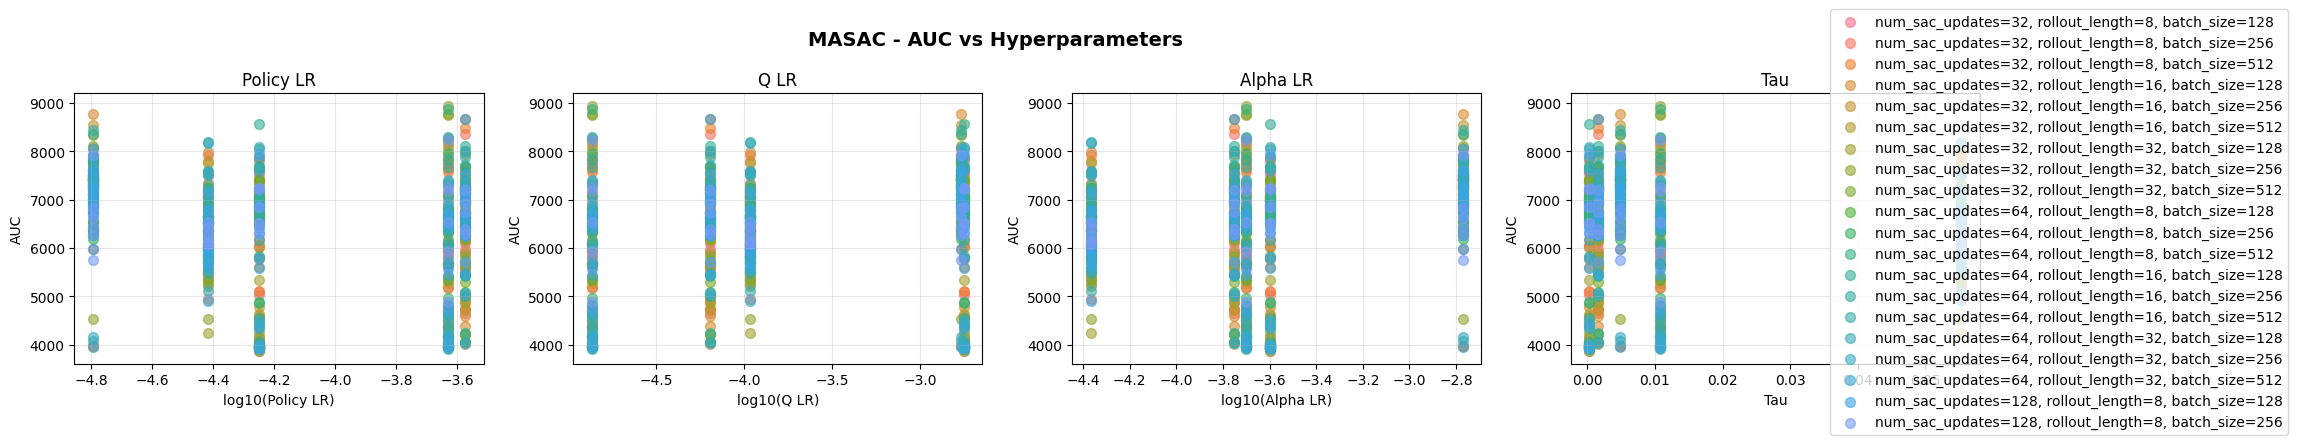

In [49]:
masac_ff_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_aa/metric/eval_returns.npy")
masac_ff_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_aa/hparam") 

fig = plot_auc_scatter_algorithm(
    masac_ff_aa_returns,
    masac_ff_aa_hp_dict,
    algorithm='masac',
    group_by=['num_sac_updates', 'rollout_length', "batch_size"]
)
fig.savefig("assistax/baselines/figs/sweep_masac_ff_armmanipulation.pdf", bbox_inches="tight")


In [50]:
performance_metrics, final_perfomance = analyze_performance(masac_ff_aa_returns, masac_ff_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 15)
Final Performance: 8673.78
AUC: 7097.18
Max Performance: 8785.38
Std Across Seeds: 857.13

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.37e-05
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 1.98e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 2.34e-04
  tau: 0.010793378
  batch_size: 512

Rank 2 (Config 72)
Final Performance: 8251.07
AUC: 6708.49
Max Performance: 8623.26
Std Across Seeds: 440.84

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.08e-04
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 4.28e-05
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 3.84e-05
  tau: 0.055368472
  batch_size: 128

Rank 3 (Config 7)
Final Performance: 8187.63
AUC: 6222.79
Max Performance: 8352.41
Std Across Seeds: 680.64

Hyperparameters:
  explore_steps: 5000
  num_updates: 4883
  q_lr: 1.08e-04
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 4.28e-05
  rollout_leng

# MASAC FF Feeding

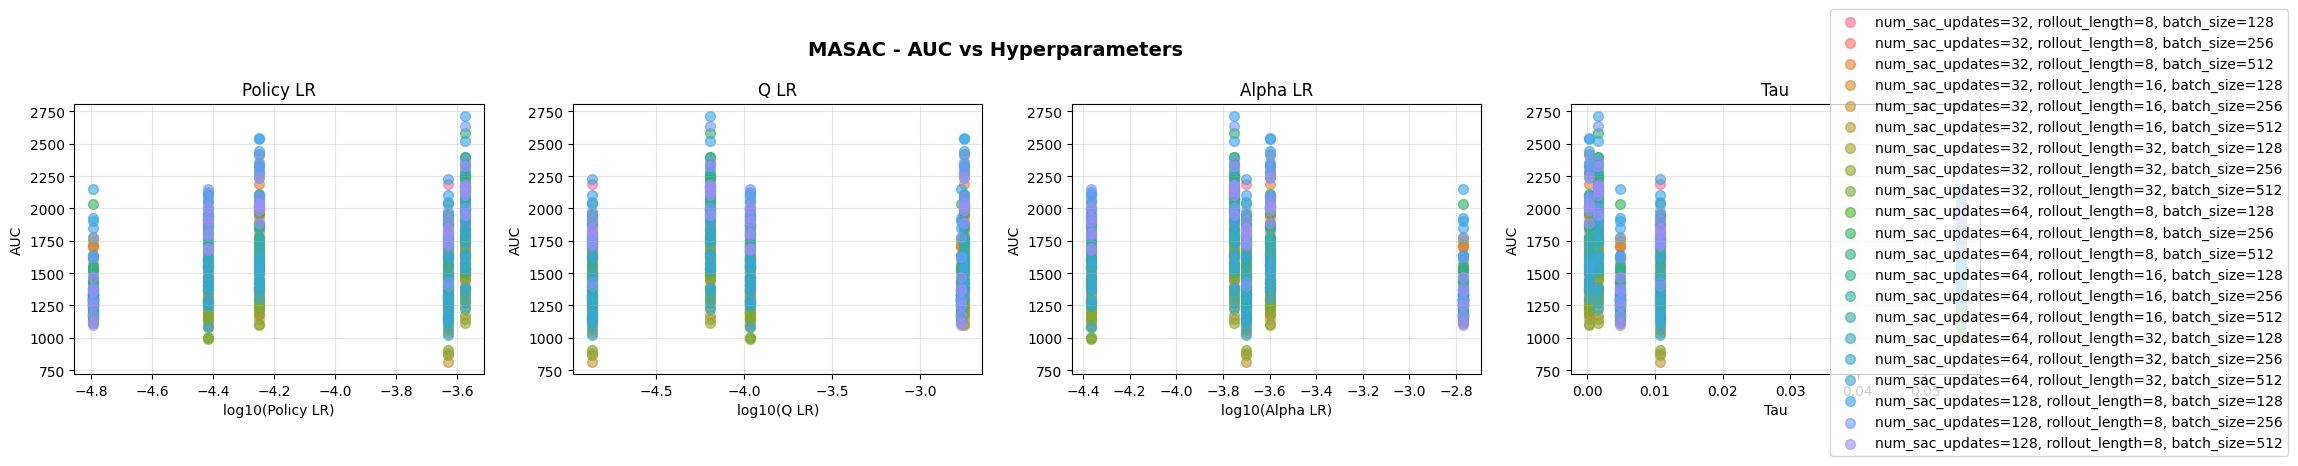

In [51]:
masac_ff_feed_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_feed/metric/eval_returns.npy")
masac_ff_feed_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_feed/hparam") 

fig = plot_auc_scatter_algorithm(
    masac_ff_feed_returns,
    masac_ff_feed_hp_dict,
    algorithm='masac',
    group_by=['num_sac_updates', 'rollout_length', "batch_size"]
)
fig.savefig("assistax/baselines/figs/sweep_masac_ff_feeding.pdf", bbox_inches="tight")


In [52]:
performance_metrics, final_perfomance = analyze_performance(masac_ff_feed_returns, masac_ff_feed_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 38)
Final Performance: 2730.55
AUC: 2373.46
Max Performance: 3056.90
Std Across Seeds: 164.59

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 128
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 5.62e-05
  tau: 0.0002728487
  batch_size: 128

Rank 2 (Config 104)
Final Performance: 2660.60
AUC: 2174.74
Max Performance: 2884.56
Std Across Seeds: 258.05

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 6.38e-05
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 1.76e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 2.67e-04
  tau: 0.0016048601
  batch_size: 256

Rank 3 (Config 49)
Final Performance: 2598.99
AUC: 2233.72
Max Performance: 3035.81
Std Across Seeds: 149.77

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 6.38e-05
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 1.76e-04
  rollou

# MASAC FF Teeth

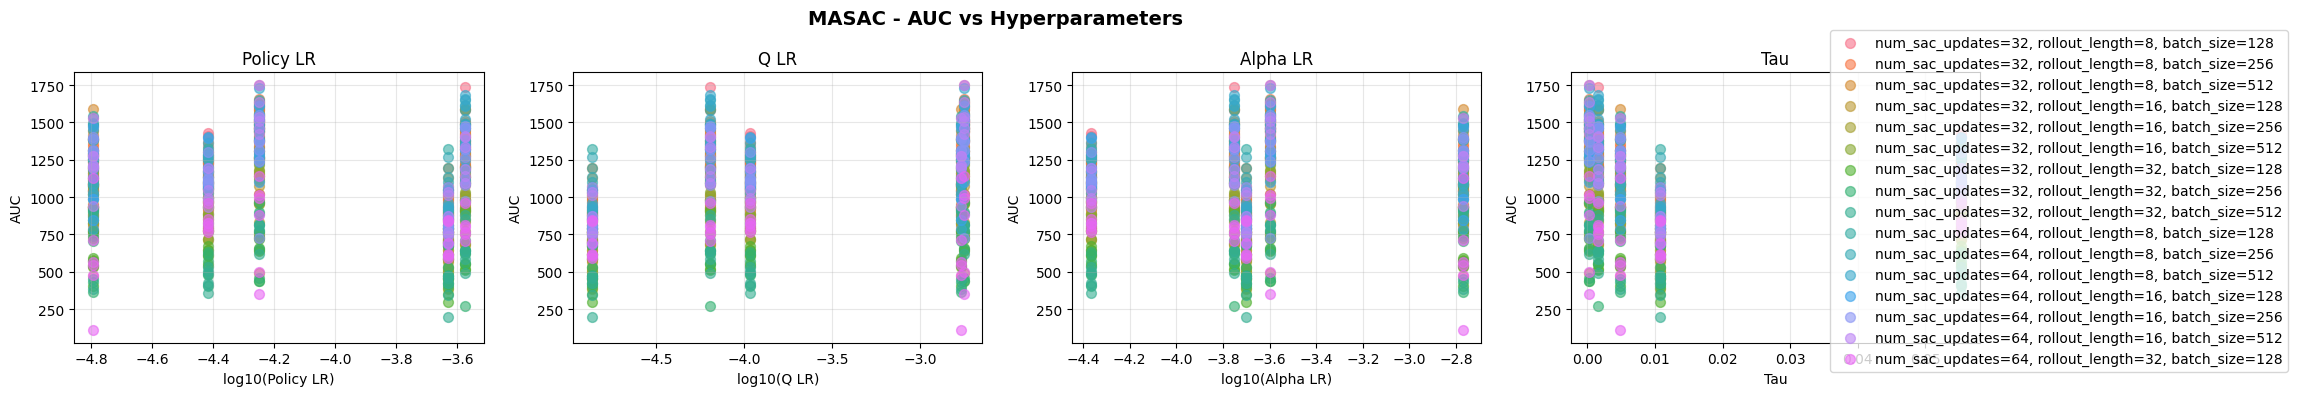

In [53]:
masac_ff_teeth_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_teeth/metric/eval_returns.npy")
masac_ff_teeth_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/masac_ff_teeth/hparam") 

fig = plot_auc_scatter_algorithm(
    masac_ff_teeth_returns,
    masac_ff_teeth_hp_dict,
    algorithm='masac',
    group_by=['num_sac_updates', 'rollout_length', "batch_size"]
)
fig.savefig("assistax/baselines/figs/sweep_masac_ff_teethbrushing.pdf", bbox_inches="tight")


In [54]:
performance_metrics, final_perfomance = analyze_performance(masac_ff_teeth_returns, masac_ff_teeth_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 93)
Final Performance: 1916.70
AUC: 1505.66
Max Performance: 2033.40
Std Across Seeds: 46.07

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 5.62e-05
  tau: 0.0002728487
  batch_size: 128

Rank 2 (Config 69)
Final Performance: 1906.96
AUC: 1523.65
Max Performance: 2029.71
Std Across Seeds: 164.00

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 6.38e-05
  num_sac_updates: 64
  num_envs: 256
  alpha_lr: 1.76e-04
  rollout_length: 8
  buffer_size: 1000000
  p_lr: 2.67e-04
  tau: 0.0016048601
  batch_size: 512

Rank 3 (Config 108)
Final Performance: 1895.66
AUC: 1410.47
Max Performance: 1983.45
Std Across Seeds: 199.64

Hyperparameters:
  explore_steps: 5000
  num_updates: 19532
  q_lr: 1.78e-03
  num_sac_updates: 32
  num_envs: 256
  alpha_lr: 2.52e-04
  rollout_